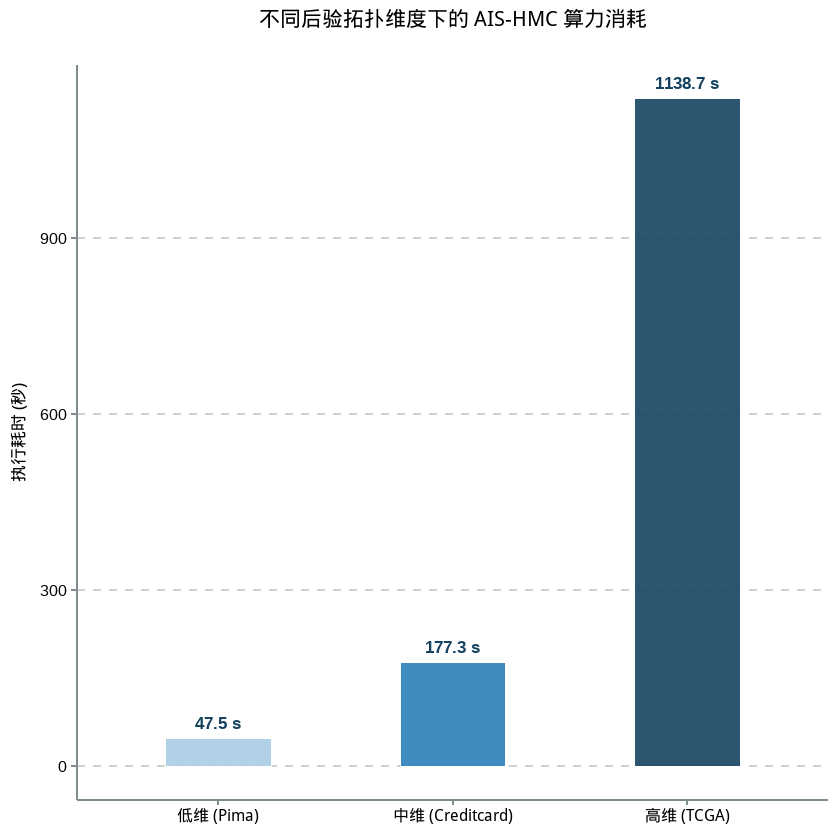

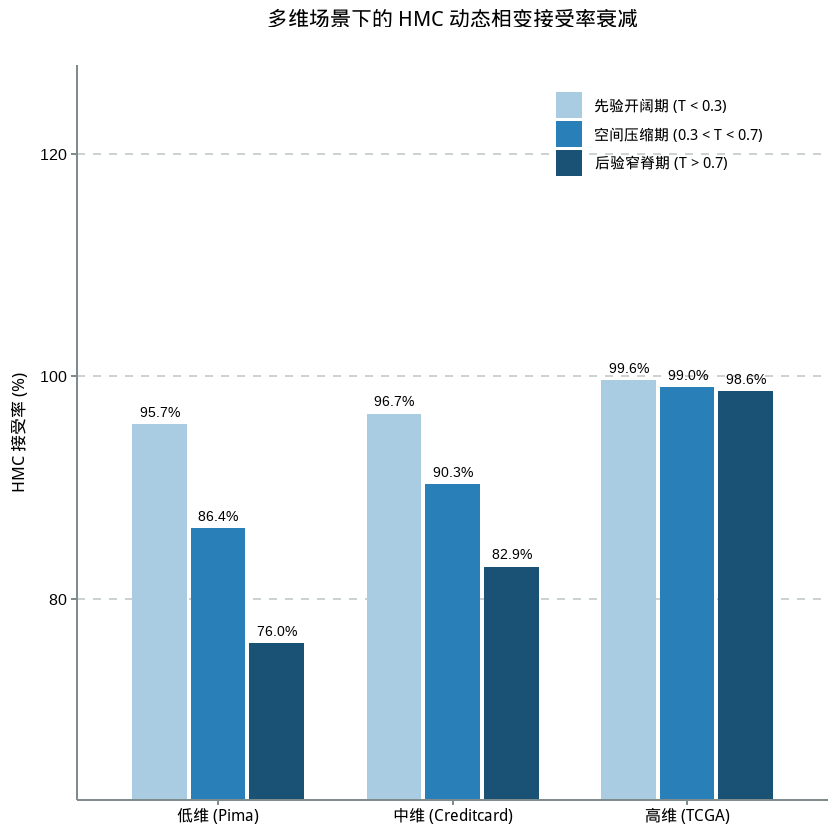

In [ ]:
library(ggplot2)
library(showtext)

showtext_auto()

C_LIGHT_BLUE <- '#A9CCE3'  
C_MID_BLUE   <- '#2980B9'   
C_DARK_BLUE  <- '#1A5276'   
C_NAVY       <- '#154360'  
C_GRAY       <- '#7F8C8D'   

dim_levels <- c('低维 (Pima)', '中维 (Creditcard)', '高维 (TCGA)')

df_runtime <- data.frame(
  Dimension = factor(dim_levels, levels = dim_levels),
  Runtime = c(47.49, 177.29, 1138.74)
)

phase_levels <- c('先验开阔期 (T < 0.3)', '空间压缩期 (0.3 < T < 0.7)', '后验窄脊期 (T > 0.7)')
df_phase <- data.frame(
  Dimension = factor(rep(dim_levels, times = 3), levels = dim_levels),
  Phase = factor(rep(phase_levels, each = 3), levels = phase_levels),
  Acceptance = c(
    95.70, 96.65, 99.64, 
    86.38, 90.32, 99.04, 
    76.05, 82.92, 98.64  
  )
)

theme_academic <- function() {
  theme_classic(base_size = 14) +
    theme(
      panel.grid.major.y = element_line(color = adjustcolor(C_GRAY, alpha.f = 0.4), linetype = "dashed"),
      axis.line = element_line(color = C_GRAY),
      axis.ticks = element_line(color = C_GRAY),
      axis.text = element_text(color = "black", size = 12),
      axis.title = element_text(color = "black", size = 13),
      plot.title = element_text(size = 16, face = "bold", hjust = 0.5, margin = margin(b = 20)),
      legend.text = element_text(size = 11),
      legend.title = element_blank(),
      legend.background = element_blank(),
      legend.key = element_blank()
    )
}

plot_runtime_explosion <- function() {
  p <- ggplot(df_runtime, aes(x = Dimension, y = Runtime, fill = Dimension)) +
    geom_col(width = 0.45, alpha = 0.9, color = "white") +
    geom_text(aes(label = sprintf("%.1f s", Runtime)), 
              vjust = -0.8, color = C_NAVY, fontface = "bold", size = 4.5) +
    scale_fill_manual(values = c(C_LIGHT_BLUE, C_MID_BLUE, C_NAVY)) +
    labs(x = NULL, y = "执行耗时 (秒)", title = "不同后验拓扑维度下的 AIS-HMC 算力消耗") +
    theme_academic() +
    theme(legend.position = "none") 
  
  print(p)
}

plot_acceptance_phase_decay <- function() {
  p <- ggplot(df_phase, aes(x = Dimension, y = Acceptance, fill = Phase)) +
    geom_col(position = position_dodge(width = 0.75), width = 0.7) +
    geom_text(aes(label = sprintf("%.1f%%", Acceptance)), 
              position = position_dodge(width = 0.75), 
              vjust = -0.8, size = 3.8, color = "black") +
    scale_fill_manual(values = c(C_LIGHT_BLUE, C_MID_BLUE, C_DARK_BLUE)) +
    coord_cartesian(ylim = c(65, 125)) +
    labs(x = NULL, y = "HMC 接受率 (%)", title = "多维场景下的 HMC 动态相变接受率衰减") +
    theme_academic() +
    theme(
      legend.position = c(0.98, 0.98),
      legend.justification = c(1, 1)
    )
  
  print(p)
}

plot_runtime_explosion()
plot_acceptance_phase_decay()